In [9]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8")


In [11]:
# Ton notebook est dans src/
# Le dataset est dans data/
# → il faut remonter d’un dossier : ../data/combined_data.csv

data_path = "../data/combined_data.csv"

df = pd.read_csv(data_path)

print("Aperçu du dataset :")
display(df.head())

print("\nInformations sur le dataset :")
print(df.info())

print("\nStatistiques descriptives :")
display(df.describe())

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Aperçu du dataset :


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81,class
0,0.160989,0.152837,0.143099,0.132230,0.121732,0.113088,0.106684,0.102206,0.097464,0.094226,...,0.268508,0.268674,0.268942,0.269235,0.269651,0.270141,0.270695,0.271260,0.271902,canola
1,0.157316,0.148315,0.139275,0.129330,0.120090,0.112003,0.105155,0.100885,0.097040,0.093725,...,0.277404,0.277630,0.277895,0.278252,0.278681,0.279293,0.279852,0.280512,0.281131,canola
2,0.180705,0.171157,0.159826,0.147212,0.136382,0.126773,0.119723,0.115086,0.109832,0.105594,...,0.304266,0.304477,0.304762,0.305169,0.305732,0.306397,0.307044,0.307668,0.308387,canola
3,0.159618,0.151638,0.141948,0.131743,0.121592,0.112819,0.106271,0.101794,0.097496,0.094452,...,0.270041,0.270336,0.270555,0.270984,0.271544,0.272093,0.272727,0.273407,0.274073,canola
4,0.147031,0.139998,0.130906,0.121395,0.112400,0.104592,0.098618,0.095303,0.091420,0.088122,...,0.247827,0.248123,0.248419,0.248833,0.249397,0.249951,0.250570,0.251253,0.251939,canola



Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Columns: 225 entries, 397.66 to class
dtypes: float64(224), str(1)
memory usage: 281.4 KB
None

Statistiques descriptives :


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,978.46,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,...,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,0.155695,0.147494,0.137796,0.127592,0.118166,0.109997,0.104044,0.099796,0.095522,0.092692,...,0.289844,0.290161,0.290508,0.290909,0.291368,0.291916,0.292514,0.293099,0.293748,0.294368
std,0.041229,0.038888,0.036317,0.033801,0.031431,0.029392,0.028044,0.026974,0.025962,0.025399,...,0.082090,0.082166,0.082233,0.082305,0.082382,0.082478,0.082561,0.082647,0.082740,0.082834
min,0.072382,0.069046,0.064929,0.060472,0.055718,0.051947,0.049500,0.048352,0.046176,0.044946,...,0.114651,0.114657,0.114760,0.114948,0.115138,0.115288,0.115448,0.115684,0.115923,0.116150
25%,0.121582,0.114697,0.107182,0.098641,0.091113,0.084116,0.079329,0.075840,0.072311,0.069909,...,0.218726,0.219011,0.219358,0.219800,0.220284,0.220836,0.221469,0.222150,0.222742,0.223284
50%,0.160588,0.152607,0.143989,0.134328,0.125113,0.116967,0.110474,0.105874,0.100950,0.097429,...,0.288602,0.288773,0.289136,0.289435,0.289775,0.290269,0.290924,0.291529,0.292216,0.292957
75%,0.182146,0.174013,0.164730,0.153764,0.143656,0.133818,0.127395,0.122779,0.117581,0.115565,...,0.366088,0.366069,0.366137,0.366571,0.367565,0.368625,0.369788,0.370831,0.371271,0.371736
max,0.243909,0.229824,0.212456,0.195551,0.180214,0.166505,0.155889,0.148502,0.140844,0.135572,...,0.428284,0.429060,0.429831,0.430596,0.431622,0.432560,0.433357,0.434270,0.435238,0.436203



Valeurs manquantes par colonne :
397.66     0
400.28     0
402.9      0
405.52     0
408.13     0
          ..
995.35     0
998.17     0
1000.99    0
1003.81    0
class      0
Length: 225, dtype: int64


In [12]:
species_col = "species"

if species_col not in df.columns:
    print(f"La colonne '{species_col}' est introuvable. Utilisation de la dernière colonne.")
    species_col = df.columns[-1]

spectral_columns = [col for col in df.columns if col != species_col]

print("Colonnes spectrales détectées :")
spectral_columns


La colonne 'species' est introuvable. Utilisation de la dernière colonne.
Colonnes spectrales détectées :


['397.66',
 '400.28',
 '402.9',
 '405.52',
 '408.13',
 '410.75',
 '413.37',
 '416.0',
 '418.62',
 '421.24',
 '423.86',
 '426.49',
 '429.12',
 '431.74',
 '434.37',
 '437.0',
 '439.63',
 '442.26',
 '444.89',
 '447.52',
 '450.16',
 '452.79',
 '455.43',
 '458.06',
 '460.7',
 '463.34',
 '465.98',
 '468.62',
 '471.26',
 '473.9',
 '476.54',
 '479.18',
 '481.83',
 '484.47',
 '487.12',
 '489.77',
 '492.42',
 '495.07',
 '497.72',
 '500.37',
 '503.02',
 '505.67',
 '508.32',
 '510.98',
 '513.63',
 '516.29',
 '518.95',
 '521.61',
 '524.27',
 '526.93',
 '529.59',
 '532.25',
 '534.91',
 '537.57',
 '540.24',
 '542.91',
 '545.57',
 '548.24',
 '550.91',
 '553.58',
 '556.25',
 '558.92',
 '561.59',
 '564.26',
 '566.94',
 '569.61',
 '572.29',
 '574.96',
 '577.64',
 '580.32',
 '583.0',
 '585.68',
 '588.36',
 '591.04',
 '593.73',
 '596.41',
 '599.1',
 '601.78',
 '604.47',
 '607.16',
 '609.85',
 '612.53',
 '615.23',
 '617.92',
 '620.61',
 '623.3',
 '626.0',
 '628.69',
 '631.39',
 '634.08',
 '636.78',
 '639.48

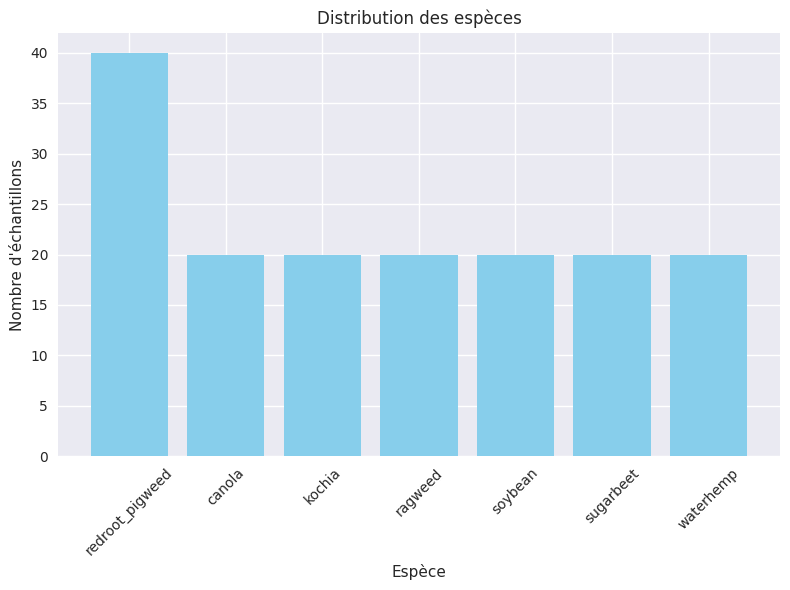

In [13]:
species_counts = df[species_col].value_counts()

plt.figure(figsize=(8,6))
plt.bar(species_counts.index, species_counts.values, color='skyblue')
plt.xlabel("Espèce")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des espèces")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


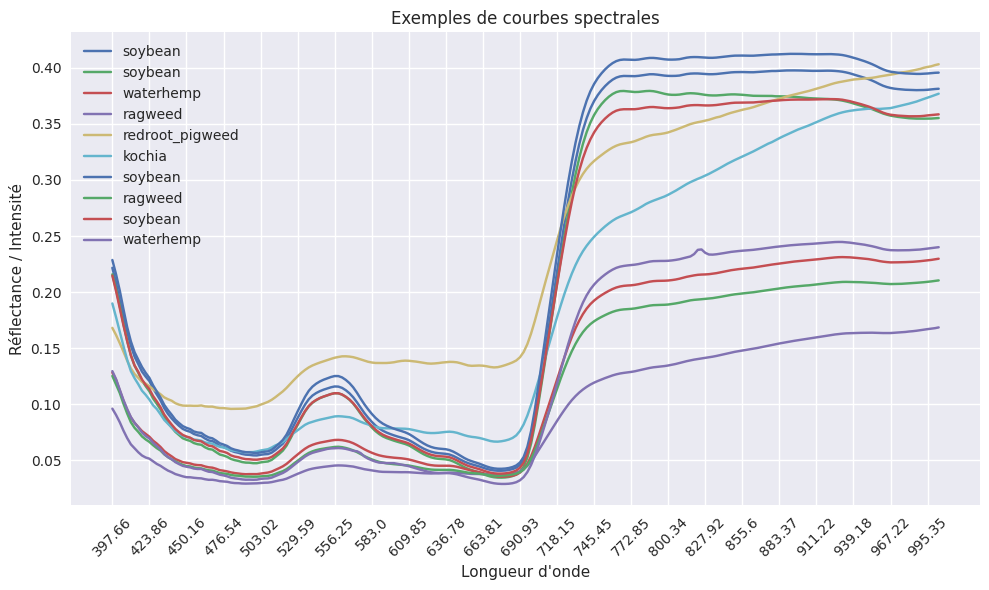

In [14]:
plt.figure(figsize=(10,6))

sample_df = df.sample(n=min(10, len(df)), random_state=42)

for _, row in sample_df.iterrows():
    spectrum = row[spectral_columns].astype(float).values
    plt.plot(spectral_columns, spectrum, label=row[species_col])

plt.xlabel("Longueur d'onde")
plt.ylabel("Réflectance / Intensité")
plt.title("Exemples de courbes spectrales")
plt.legend()

step = 10 if len(spectral_columns) > 10 else 1
plt.xticks(np.arange(0, len(spectral_columns), step), spectral_columns[::step], rotation=45)

plt.tight_layout()
plt.show()


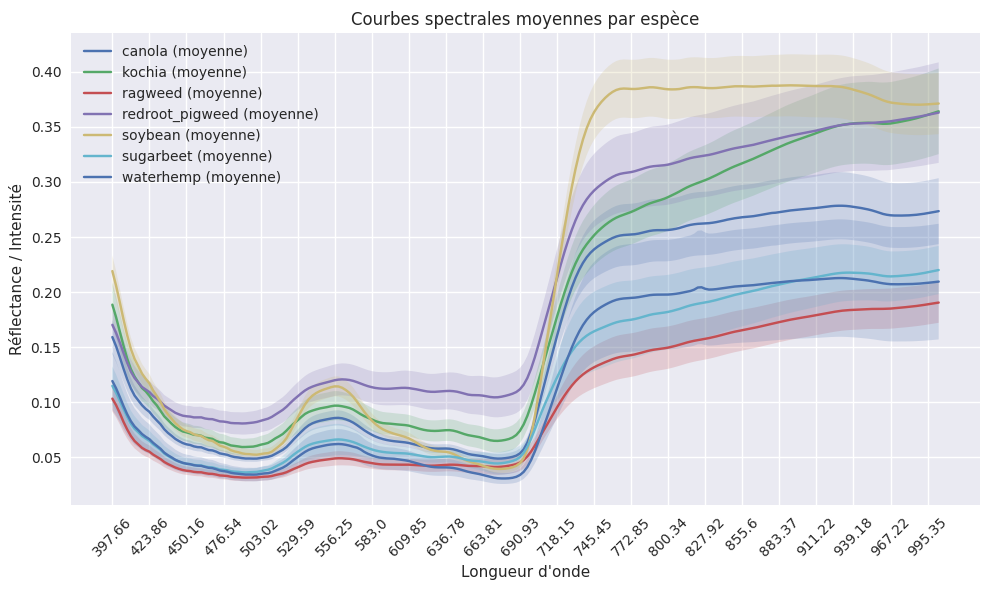

In [15]:
unique_species = df[species_col].unique()

plt.figure(figsize=(10,6))

for species in unique_species:
    subset = df[df[species_col] == species]
    spectra = subset[spectral_columns].astype(float)
    mean_spectrum = spectra.mean()
    std_spectrum = spectra.std()

    plt.plot(spectral_columns, mean_spectrum, label=f"{species} (moyenne)")
    plt.fill_between(spectral_columns, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum, alpha=0.2)

plt.xlabel("Longueur d'onde")
plt.ylabel("Réflectance / Intensité")
plt.title("Courbes spectrales moyennes par espèce")
plt.legend()

plt.xticks(np.arange(0, len(spectral_columns), step), spectral_columns[::step], rotation=45)

plt.tight_layout()
plt.show()


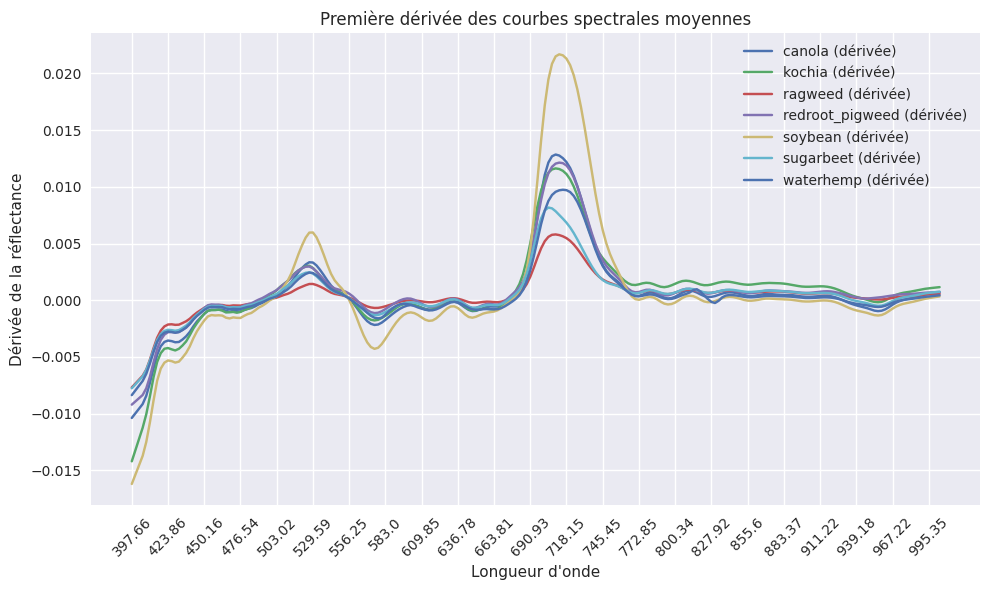

In [16]:
plt.figure(figsize=(10,6))

window_length = 7
polyorder = 2

for species in unique_species:
    subset = df[df[species_col] == species]
    spectra = subset[spectral_columns].astype(float)
    mean_spectrum = spectra.mean().values

    if window_length > len(mean_spectrum):
        window_length = len(mean_spectrum) if len(mean_spectrum) % 2 != 0 else len(mean_spectrum)-1

    first_derivative = savgol_filter(mean_spectrum, window_length, polyorder, deriv=1)
    plt.plot(spectral_columns, first_derivative, label=f"{species} (dérivée)")

plt.xlabel("Longueur d'onde")
plt.ylabel("Dérivée de la réflectance")
plt.title("Première dérivée des courbes spectrales moyennes")
plt.legend()

plt.xticks(np.arange(0, len(spectral_columns), step), spectral_columns[::step], rotation=45)

plt.tight_layout()
plt.show()


Variance expliquée : [0.94667476 0.04169519]


/tmp/ipykernel_12413/1851343022.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PC1"] = pca_result[:, 0]
/tmp/ipykernel_12413/1851343022.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PC2"] = pca_result[:, 1]


,PC1,PC2
0,-0.089114,-0.110544
1,-0.031948,-0.065378
2,0.257256,-0.088679
3,-0.138007,-0.037605
4,-0.378138,-0.033335


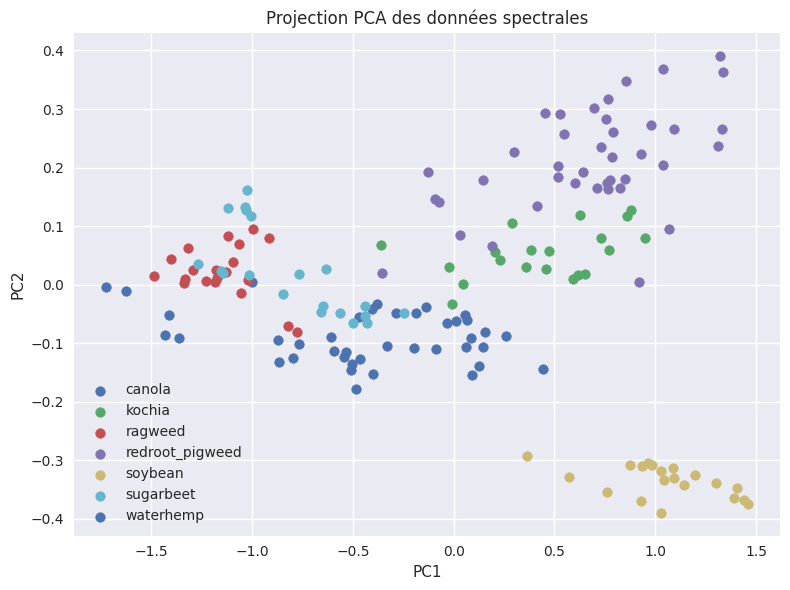

In [17]:
spectra_data = df[spectral_columns].astype(float)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(spectra_data)

df["PC1"] = pca_result[:, 0]
df["PC2"] = pca_result[:, 1]

print("Variance expliquée :", pca.explained_variance_ratio_)
display(df[["PC1", "PC2"]].head())

plt.figure(figsize=(8,6))
for species in unique_species:
    subset = df[df[species_col] == species]
    plt.scatter(subset["PC1"], subset["PC2"], label=species)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA des données spectrales")
plt.legend()
plt.tight_layout()
plt.show()


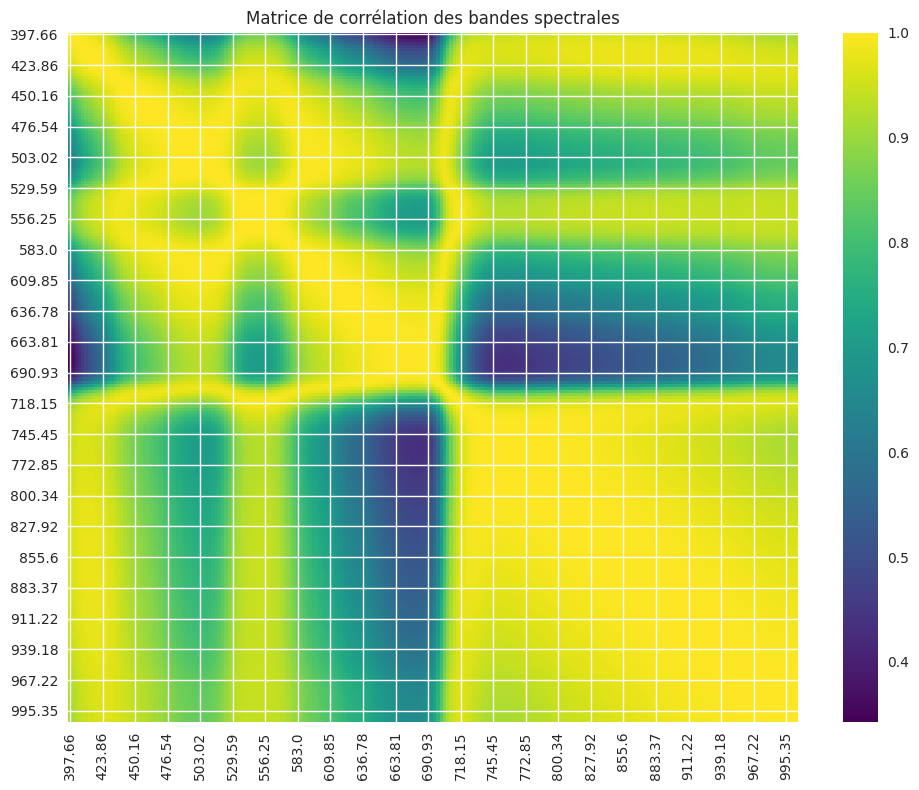

In [18]:
corr_matrix = spectra_data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Matrice de corrélation des bandes spectrales")

plt.xticks(np.arange(0, len(spectral_columns), step), spectral_columns[::step], rotation=90)
plt.yticks(np.arange(0, len(spectral_columns), step), spectral_columns[::step])

plt.tight_layout()
plt.show()
